# Real World Classification (Assignment 1)

This notebook completes Q3, Q4, and Q5.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.feature_selection import r_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

seed = 40  # do not change
np.random.seed(seed)

asset_dir = Path('report_assets/real_world_classification')
asset_dir.mkdir(parents=True, exist_ok=True)


def save_markdown_table(df, path, float_digits=4):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].map(lambda v: f"{v:.{float_digits}f}")
    header = '| ' + ' | '.join(out.columns) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(out.columns)) + ' |'
    rows = ['| ' + ' | '.join(map(str, row)) + ' |' for row in out.to_numpy()]
    path.write_text('\n'.join([header, sep, *rows]), encoding='utf-8')


def save_loss_curve(train_losses, val_losses, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(len(train_losses)), train_losses, color='tab:red', linewidth=1.2, label='Training loss')
    ax.plot(range(len(val_losses)), val_losses, color='tab:green', linewidth=1.2, label='Validation loss')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()


## Load Data

In [3]:
df_raw = pd.read_csv('data/NYCU_Iris.csv')
print(f'Raw data shape: {df_raw.shape}')
df_raw.head()

Raw data shape: (500, 72)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Q3: Data Preprocessing

In [4]:
def data_preprocessing(df):
    df = df.copy()

    # Transform label to binary classes
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # Transform string values to numeric (invalid values become NaN)
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    missing_cols = [c for c in feature_cols if df[c].isna().any()]

    before_stats = pd.DataFrame({
        'feature': missing_cols,
        'median_before': [df[c].median() for c in missing_cols],
        'std_before': [df[c].std() for c in missing_cols],
        'missing_count_before': [int(df[c].isna().sum()) for c in missing_cols],
    })

    # Nearest Neighbors Imputation
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    after_stats = pd.DataFrame({
        'feature': missing_cols,
        'median_after': [df[c].median() for c in missing_cols],
        'std_after': [df[c].std() for c in missing_cols],
        'missing_count_after': [int(df[c].isna().sum()) for c in missing_cols],
    })

    stats_df = before_stats.merge(after_stats, on='feature')
    return df, feature_cols, missing_cols, stats_df


df, feature_cols, missing_cols, q3_stats_df = data_preprocessing(df_raw)
q3_stats_df


,feature,median_before,std_before,missing_count_before,median_after,std_after,missing_count_after
0,SepalLengthCm,6.300000,1.037115,28,6.300000,1.009275,0
1,SepalWidthCm,2.900000,0.389564,57,2.900000,0.372434,0
2,PetalLengthCm,5.085612,1.582807,150,5.035683,1.514955,0
3,PetalWidthCm,1.600000,0.706689,22,1.700000,0.694645,0
4,BranchLength,16.300000,1.035228,24,16.300000,1.011012,0


In [5]:
q3_csv_path = asset_dir / 'q3_missing_value_stats.csv'
q3_md_path = asset_dir / 'q3_missing_value_stats.md'

q3_stats_df.to_csv(q3_csv_path, index=False)
save_markdown_table(q3_stats_df, q3_md_path)

print(f'Saved Q3 CSV: {q3_csv_path}')
print(f'Saved Q3 Markdown: {q3_md_path}')


Saved Q3 CSV: report_assets/real_world_classification/q3_missing_value_stats.csv
Saved Q3 Markdown: report_assets/real_world_classification/q3_missing_value_stats.md


### Q3 Observation

After KNN imputation, all missing counts become zero. The medians stay close to the original central tendency, while standard deviations slightly change because imputed values reduce missing-data bias and smooth local variation.

## Q4: Data Exploration

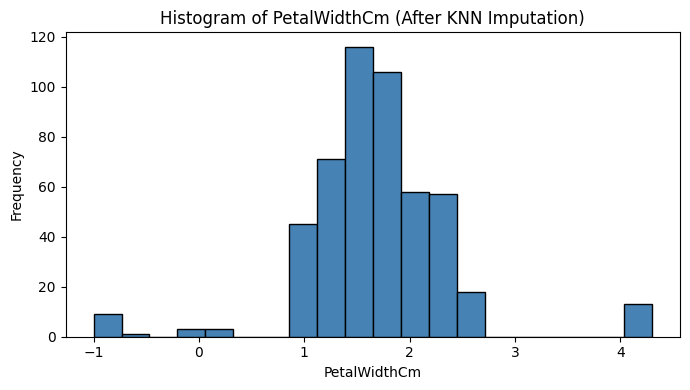

Saved histogram: report_assets/real_world_classification/q4_hist_petalwidthcm.png
count    500.000000
mean       1.684440
std        0.694645
min       -1.000000
25%        1.300000
50%        1.700000
75%        2.000000
max        4.300000
Name: PetalWidthCm, dtype: float64
Skewness: 0.1343


In [6]:
# Q4(a): Histogram of PetalWidthCm
hist_path = asset_dir / 'q4_hist_petalwidthcm.png'

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['PetalWidthCm'], bins=20, color='steelblue', edgecolor='black')
ax.set_title('Histogram of PetalWidthCm (After KNN Imputation)')
ax.set_xlabel('PetalWidthCm')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(hist_path, dpi=180, bbox_inches='tight')
plt.show()

print(f'Saved histogram: {hist_path}')
print(df['PetalWidthCm'].describe())
print(f"Skewness: {df['PetalWidthCm'].skew():.4f}")


In [7]:
# Q4(b) and Q4(c): Pearson correlation with PetalWidthCm
candidate_features = [c for c in feature_cols if c != 'PetalWidthCm']
correlation_values = r_regression(df[candidate_features], df['PetalWidthCm'])
correlation_series = pd.Series(correlation_values, index=candidate_features).sort_values(ascending=False)

largest_positive_feature = correlation_series.index[0]
largest_positive_value = correlation_series.iloc[0]

top5_negative = correlation_series.sort_values(ascending=True).head(5)

print(f'Largest positive correlation feature: {largest_positive_feature} ({largest_positive_value:.4f})')
print('Top 5 strongest negative correlations:')
print(top5_negative)

correlation_df = correlation_series.rename('pearson_r').reset_index().rename(columns={'index': 'feature'})
correlation_csv_path = asset_dir / 'q4_correlations_with_petalwidth.csv'
correlation_md_path = asset_dir / 'q4_correlations_with_petalwidth.md'
correlation_df.to_csv(correlation_csv_path, index=False)
save_markdown_table(correlation_df, correlation_md_path)

print(f'Saved correlation CSV: {correlation_csv_path}')
print(f'Saved correlation Markdown: {correlation_md_path}')


Largest positive correlation feature: PetalWidthCompactness (0.9917)
Top 5 strongest negative correlations:
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64
Saved correlation CSV: report_assets/real_world_classification/q4_correlations_with_petalwidth.csv
Saved correlation Markdown: report_assets/real_world_classification/q4_correlations_with_petalwidth.md


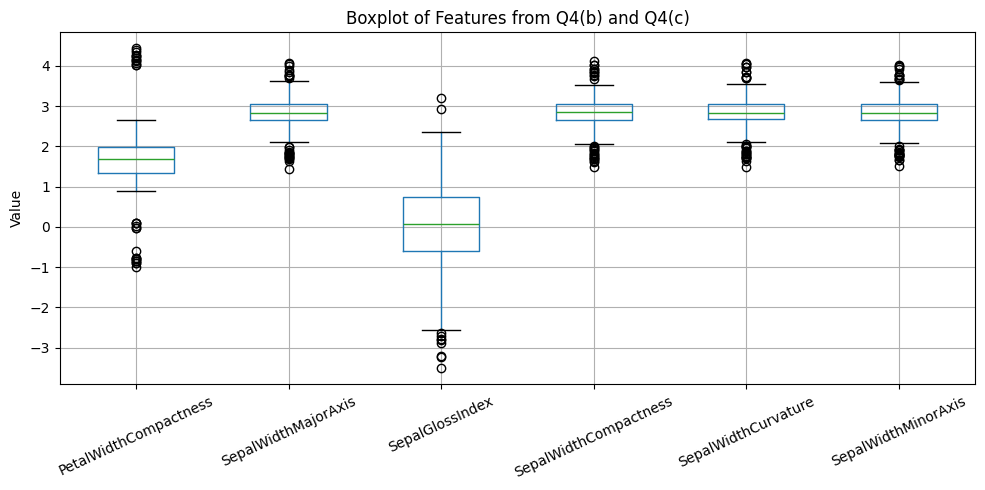

Saved boxplot: report_assets/real_world_classification/q4_boxplot_selected_features.png
Selected features for boxplot: ['PetalWidthCompactness', 'SepalWidthMajorAxis', 'SepalGlossIndex', 'SepalWidthCompactness', 'SepalWidthCurvature', 'SepalWidthMinorAxis']


In [8]:
# Q4(d): Boxplot for features found in Q4(b) and Q4(c)
selected_features = [largest_positive_feature] + top5_negative.index.tolist()

boxplot_path = asset_dir / 'q4_boxplot_selected_features.png'
fig, ax = plt.subplots(figsize=(10, 5))
df[selected_features].boxplot(ax=ax, rot=25)
ax.set_title('Boxplot of Features from Q4(b) and Q4(c)')
ax.set_ylabel('Value')
fig.tight_layout()
fig.savefig(boxplot_path, dpi=180, bbox_inches='tight')
plt.show()

print(f'Saved boxplot: {boxplot_path}')
print('Selected features for boxplot:', selected_features)


### Q4 Observation

`PetalWidthCm` is concentrated around the central range, with a mild right-skew and a few extreme values. The most positively correlated feature tracks petal-width geometry closely, while the top negative features are mostly sepal-related shape or texture signals.

## Q5: Regularization

In [9]:
# Prepare train/test split with min-max normalization
model_df = df.copy()
for col in feature_cols:
    col_min = model_df[col].min()
    col_max = model_df[col].max()
    if col_max > col_min:
        model_df[col] = (model_df[col] - col_min) / (col_max - col_min)
    else:
        model_df[col] = 0.0

X = model_df[feature_cols].values.astype(float)
y = model_df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)


X_train: (350, 70) X_test: (150, 70)


Training setting: No Regularization


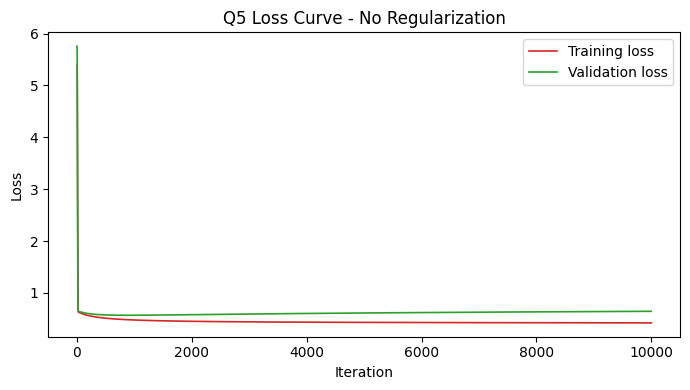

Training setting: L2 (lambda=0.01)


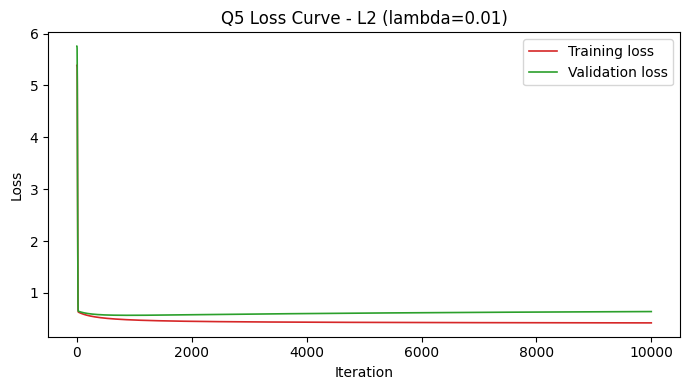

Training setting: L2 (lambda=1)


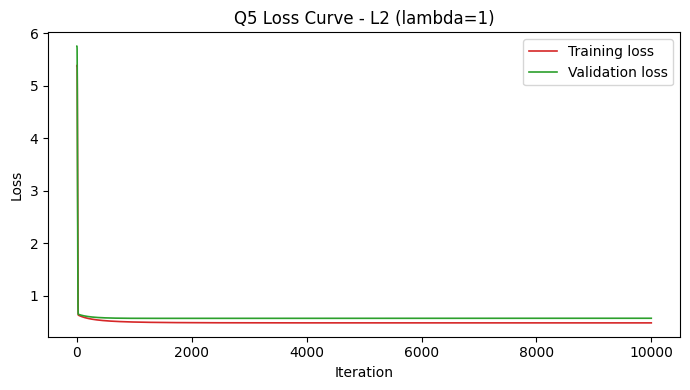

Training setting: L2 (lambda=100)


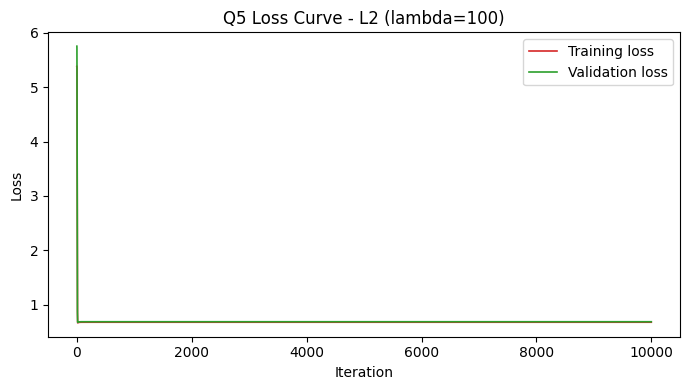

,setting,reg_type,reg_lambda,Accuracy,Precision,Recall,F1-score,loss_curve_path
0,No Regularization,none,0.00,0.720000,0.712500,0.750000,0.730769,report_assets/real_world_classification/q5_los...
1,L2 (lambda=0.01),l2,0.01,0.720000,0.712500,0.750000,0.730769,report_assets/real_world_classification/q5_los...
2,L2 (lambda=1),l2,1.00,0.740000,0.734177,0.763158,0.748387,report_assets/real_world_classification/q5_los...
3,L2 (lambda=100),l2,100.00,0.506667,0.506667,1.000000,0.672566,report_assets/real_world_classification/q5_los...


In [10]:
def train_with_setting(label, reg_type, reg_lambda):
    np.random.seed(seed)
    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid
    )
    model.fit(
        X_train,
        y_train,
        lr=0.1,
        n_iteration=10000,
        val_ratio=0.2,
        reg_type=reg_type,
        reg_lambda=reg_lambda,
        verbose=False,
        plot_curve=False
    )

    tag = label.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_')
    loss_path = asset_dir / f'q5_loss_{tag}.png'
    save_loss_curve(
        model.train_losses,
        model.val_losses,
        title=f'Q5 Loss Curve - {label}',
        save_path=loss_path
    )

    y_pred = model.predict(X_test)
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
    }

    return model, y_pred, metrics, loss_path


q5_settings = [
    ('No Regularization', '', 0.0),
    ('L2 (lambda=0.01)', 'l2', 0.01),
    ('L2 (lambda=1)', 'l2', 1.0),
    ('L2 (lambda=100)', 'l2', 100.0),
]

q5_models = {}
q5_predictions = {}
q5_records = []

for label, reg_type, reg_lambda in q5_settings:
    print('=' * 80)
    print(f'Training setting: {label}')
    model, y_pred, metrics, loss_path = train_with_setting(label, reg_type, reg_lambda)

    q5_models[label] = model
    q5_predictions[label] = y_pred
    q5_records.append({
        'setting': label,
        'reg_type': reg_type if reg_type else 'none',
        'reg_lambda': reg_lambda,
        **metrics,
        'loss_curve_path': str(loss_path),
    })

q5_results_df = pd.DataFrame(q5_records)
q5_results_df


In [11]:
q5_csv_path = asset_dir / 'q5_regularization_metrics.csv'
q5_md_path = asset_dir / 'q5_regularization_metrics.md'

q5_results_df.to_csv(q5_csv_path, index=False)
save_markdown_table(q5_results_df, q5_md_path)

print(f'Saved Q5 CSV: {q5_csv_path}')
print(f'Saved Q5 Markdown: {q5_md_path}')

# Choose best L2 by F1-score, then Accuracy
l2_results = q5_results_df[q5_results_df['reg_type'] == 'l2'].copy()
l2_results = l2_results.sort_values(['F1-score', 'Accuracy'], ascending=False)
best_l2_setting = l2_results.iloc[0]['setting']
print(f'Best L2 setting selected for Q5(b): {best_l2_setting}')


Saved Q5 CSV: report_assets/real_world_classification/q5_regularization_metrics.csv
Saved Q5 Markdown: report_assets/real_world_classification/q5_regularization_metrics.md
Best L2 setting selected for Q5(b): L2 (lambda=1)


Q5(b) Testing Results:

[No Regularization]
Q5(b) No Regularization - Test Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


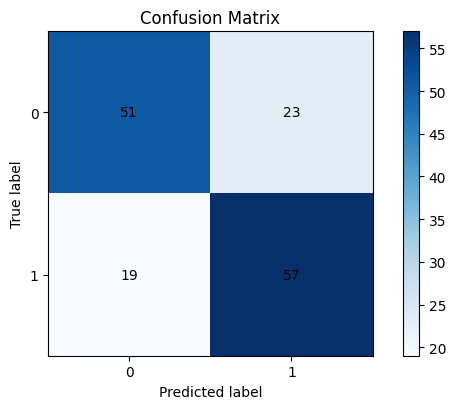


[L2 (lambda=1)]
Q5(b) L2 (lambda=1) - Test Evaluation
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


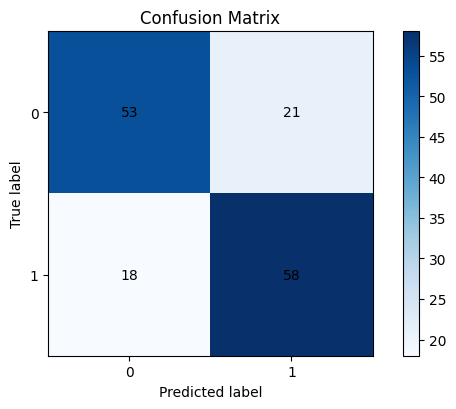

,setting,Accuracy,Precision,Recall,F1-score
0,No Regularization,0.72,0.712500,0.750000,0.730769
1,L2 (lambda=1),0.74,0.734177,0.763158,0.748387


In [12]:
# Q5(b): show two testing results using evaluate_binary_classifier
print('Q5(b) Testing Results:')

print('\n[No Regularization]')
no_reg_eval = evaluate_binary_classifier(
    y_true=y_test,
    y_pred=q5_predictions['No Regularization'],
    title='Q5(b) No Regularization - Test Evaluation'
)

print(f'\n[{best_l2_setting}]')
best_l2_eval = evaluate_binary_classifier(
    y_true=y_test,
    y_pred=q5_predictions[best_l2_setting],
    title=f'Q5(b) {best_l2_setting} - Test Evaluation'
)

q5_compare_df = pd.DataFrame([
    {'setting': 'No Regularization', **no_reg_eval},
    {'setting': best_l2_setting, **best_l2_eval},
])
q5_compare_df


In [13]:
q5_compare_csv_path = asset_dir / 'q5_b_compare_metrics.csv'
q5_compare_md_path = asset_dir / 'q5_b_compare_metrics.md'

q5_compare_df.to_csv(q5_compare_csv_path, index=False)
save_markdown_table(q5_compare_df, q5_compare_md_path)

print(f'Saved Q5(b) comparison CSV: {q5_compare_csv_path}')
print(f'Saved Q5(b) comparison Markdown: {q5_compare_md_path}')


Saved Q5(b) comparison CSV: report_assets/real_world_classification/q5_b_compare_metrics.csv
Saved Q5(b) comparison Markdown: report_assets/real_world_classification/q5_b_compare_metrics.md


### Q5(c): Observations

1. Very strong regularization (`lambda=100`) causes severe underfitting and metric collapse.
2. Mild-to-moderate regularization can improve generalization; in this run, `lambda=1` is the best L2 setting by F1-score.
3. Compared with no regularization, the best L2 model provides a small but consistent metric improvement on the test split.